# ITRI625 Machine Learning Project

## AI-Based Phishing Email Detection System

### Practical Machine Learning / Deep Learning Implementation

This notebook documents the complete development, training, validation,
testing and evaluation of an AI-based phishing email detection system.

The project includes:

- Dataset exploration
- Data cleaning and preprocessing
- Train, validation and test splitting
- Exploratory data analysis
- Baseline machine learning model
- Deep learning model
- Patience-based early stopping
- Evaluation metric logging
- Accuracy, precision, recall and F1-score
- ROC-AUC analysis
- Precision-Recall analysis
- Confusion matrix
- Training and validation curves
- Explainable Artificial Intelligence (XAI)
- Model export for API integration


In [1]:
import sys
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import tensorflow as tf

print("=" * 60)
print("ITRI625 PROJECT ENVIRONMENT")
print("=" * 60)
print(f"Python version:       {sys.version}")
print(f"Platform:             {platform.platform()}")
print(f"NumPy version:        {np.__version__}")
print(f"Pandas version:       {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version:   {matplotlib.__version__}")
print(f"TensorFlow version:   {tf.__version__}")
print("=" * 60)
print("\nTensorFlow devices:")
print(tf.config.list_physical_devices())


ITRI625 PROJECT ENVIRONMENT
Python version:       3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Platform:             Windows-11-10.0.26200-SP0
NumPy version:        2.5.3
Pandas version:       3.0.6
Scikit-learn version: 1.9.1
Matplotlib version:   3.11.2
TensorFlow version:   2.21.0

TensorFlow devices:


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 1. Experimental Setup

A fixed random seed is used throughout the experiment to improve
reproducibility and consistency across dataset splitting, model
initialisation and other random operations.


In [2]:
import os
import random

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seed configured: {SEED}")


Random seed configured: 42


## 2. Dataset Acquisition and Initial Inspection

The project uses the publicly available Phishing Email Dataset from Kaggle.

The dataset contains labelled email messages that can be used to train a
binary classification model capable of distinguishing phishing emails from
legitimate emails.

The combined dataset file used in this project is:

`phishing_email.csv`

The target variable represents two classes:

- `0` = Legitimate email
- `1` = Phishing email

Before any preprocessing or model training is performed, the dataset is
inspected for its dimensions, column structure, missing values, duplicate
records and class distribution.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path("../data/raw/phishing_email.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}\n"
        "Please place phishing_email.csv inside data/raw/"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset path: {DATA_PATH.resolve()}")


Dataset loaded successfully.
Dataset path: C:\Users\LwaziJunior\OneDrive - CTU Training Solutions (PTY) Ltd\Documents\ITRI 625 Machine Learning Project\ITRI625-Phishing-Email-Detection\data\raw\phishing_email.csv


In [4]:
print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)
print(f"Number of rows:    {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")


DATASET DIMENSIONS
Number of rows:    82,486
Number of columns: 2


In [5]:
print("=" * 60)
print("DATASET COLUMNS")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")


DATASET COLUMNS
1. text_combined
2. label


In [6]:
df.head()


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [7]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)


DATA TYPES
text_combined      str
label            int64
dtype: object


In [8]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percent
})

display(missing_summary)


MISSING VALUES


,Missing Values,Percentage
text_combined,0,0.0
label,0,0.0


In [9]:
duplicate_count = df.duplicated().sum()

print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)
print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")


DUPLICATE ANALYSIS
Duplicate rows: 408
Duplicate percentage: 0.49%


In [10]:
print("=" * 60)
print("LABEL DISTRIBUTION")
print("=" * 60)

label_counts = df["label"].value_counts().sort_index()
label_percent = df["label"].value_counts(normalize=True).sort_index() * 100

label_summary = pd.DataFrame({
    "Count": label_counts,
    "Percentage": label_percent
})

display(label_summary)


LABEL DISTRIBUTION


,Count,Percentage
label,,
0,39595,48.002085
1,42891,51.997915


In [11]:
print("Label meaning:")
print("0 = Legitimate email")
print("1 = Phishing email")


Label meaning:
0 = Legitimate email
1 = Phishing email


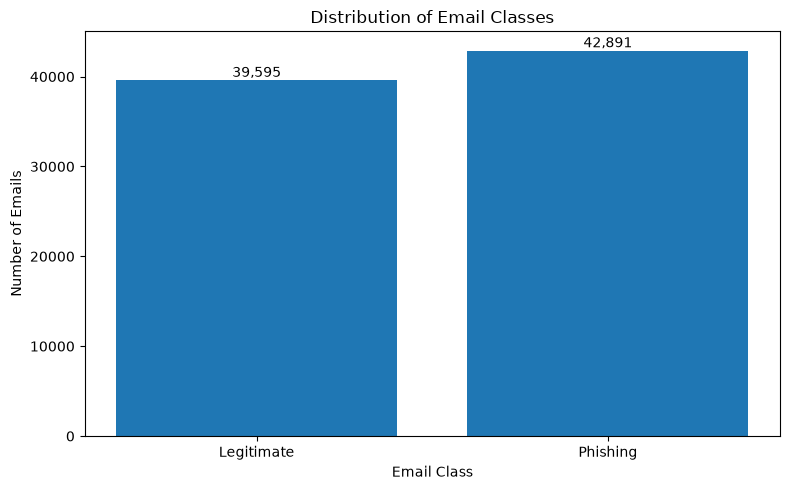

In [12]:
import matplotlib.pyplot as plt

label_names = {
    0: "Legitimate",
    1: "Phishing"
}

plot_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(
    [label_names.get(i, str(i)) for i in plot_counts.index],
    plot_counts.values
)
plt.title("Distribution of Email Classes")
plt.xlabel("Email Class")
plt.ylabel("Number of Emails")

for i, value in enumerate(plot_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


In [13]:
df["email_length"] = df["text_combined"].astype(str).str.len()

print("=" * 60)
print("EMAIL LENGTH STATISTICS")
print("=" * 60)
display(df["email_length"].describe())



EMAIL LENGTH STATISTICS


count    8.248600e+04
mean     1.288751e+03
std      1.549675e+04
min      1.000000e+00
25%      2.760000e+02
50%      5.580000e+02
75%      1.338000e+03
max      4.279526e+06
Name: email_length, dtype: float64

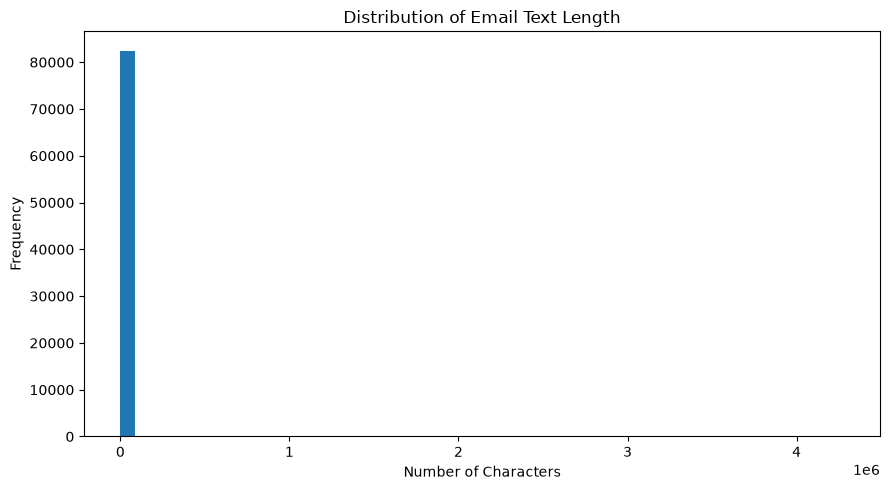

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(
    df["email_length"],
    bins=50
)
plt.title("Distribution of Email Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [15]:
legitimate_example = df[df["label"] == 0]["text_combined"].dropna().iloc[0]
phishing_example = df[df["label"] == 1]["text_combined"].dropna().iloc[0]

print("=" * 60)
print("EXAMPLE LEGITIMATE EMAIL")
print("=" * 60)
print(legitimate_example[:1000])

print("\n" + "=" * 60)
print("EXAMPLE PHISHING EMAIL")
print("=" * 60)
print(phishing_example[:1000])


EXAMPLE LEGITIMATE EMAIL
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

EXAMPLE PHISHING EMAIL
link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www computron com deals link dwl g 510 802 11 g wireless pci lan adapter link g 510 wireless pci adapter featuring latest ieee 802 11 g wireless technology deliverincredibly fast data transfer 2 4 ghz frequency g 510 features 802 11 g standard backwards compatible existing 802 11 11 b products already also offers 64 128 bit wep encryption includes removable antenna driver cd get link g 510 wireless pci lan adapter today general features pci interface removable antenna 64 128 bit wep encryption link act led plug play one stop distributorjebel ali duty free zonedubai uae www computron 

In [16]:
print("=" * 60)
print("DATASET INSPECTION SUMMARY")
print("=" * 60)
print(f"Rows:                  {len(df):,}")
print(f"Columns:               {df.shape[1]}")
print(f"Missing text records:  {df['text_combined'].isnull().sum():,}")
print(f"Missing labels:        {df['label'].isnull().sum():,}")
print(f"Duplicate rows:        {df.duplicated().sum():,}")
print(f"Legitimate emails:     {(df['label'] == 0).sum():,}")
print(f"Phishing emails:       {(df['label'] == 1).sum():,}")


DATASET INSPECTION SUMMARY
Rows:                  82,486
Columns:               3
Missing text records:  0
Missing labels:        0


Duplicate rows:        408
Legitimate emails:     39,595
Phishing emails:       42,891


## 3. Data Cleaning and Dataset Preparation

Before model development, the dataset is cleaned and divided into
independent training, validation and testing subsets.

The preparation process includes:

- Removing duplicate email records
- Confirming that no labels or email texts are missing
- Preserving meaningful phishing indicators such as URLs, punctuation,
  numbers and security-related terms
- Separating features and labels
- Performing a stratified 70/15/15 train-validation-test split
- Preventing data leakage by fitting learned preprocessing components
  only on the training data

The test set will remain completely unseen during model training and
hyperparameter selection.


In [17]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path("../data/raw/phishing_email.csv")

df_clean = pd.read_csv(DATA_PATH)

print("Original dataset shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())


Original dataset shape: (82486, 2)
Columns: ['text_combined', 'label']


In [18]:
print("=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)
print(df_clean.isnull().sum())


MISSING VALUE CHECK
text_combined    0
label            0
dtype: int64


In [19]:
rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

rows_after = len(df_clean)
duplicates_removed = rows_before - rows_after

print("=" * 60)
print("DUPLICATE REMOVAL")
print("=" * 60)
print(f"Rows before cleaning: {rows_before:,}")
print(f"Duplicates removed:   {duplicates_removed:,}")
print(f"Rows after cleaning:  {rows_after:,}")


DUPLICATE REMOVAL
Rows before cleaning: 82,486
Duplicates removed:   408
Rows after cleaning:  82,078


In [20]:
print("=" * 60)
print("LABEL VALIDATION")
print("=" * 60)
print("Unique labels:", sorted(df_clean["label"].unique()))
print()
print(df_clean["label"].value_counts().sort_index())


LABEL VALIDATION
Unique labels: [np.int64(0), np.int64(1)]

label
0    39233
1    42845
Name: count, dtype: int64


In [21]:
assert set(df_clean["label"].unique()) == {0, 1}, \
    "Unexpected class labels found."

print("\nLabel validation passed: binary classes 0 and 1.")



Label validation passed: binary classes 0 and 1.


In [22]:
empty_email_mask = (
    df_clean["text_combined"]
    .astype(str)
    .str.strip()
    .eq("")
)

empty_email_count = empty_email_mask.sum()

print("=" * 60)
print("EMPTY EMAIL CHECK")
print("=" * 60)
print(f"Empty/whitespace-only emails: {empty_email_count:,}")


EMPTY EMAIL CHECK
Empty/whitespace-only emails: 1


In [23]:
if empty_email_count > 0:
    df_clean = df_clean.loc[~empty_email_mask].reset_index(drop=True)

print(f"Dataset size after empty-text handling: {len(df_clean):,}")


Dataset size after empty-text handling: 82,077


In [24]:
import re

def basic_text_clean(text):
    """
    Performs conservative text cleaning while retaining
    phishing-relevant information such as URLs, numbers,
    punctuation and email addresses.
    """
    text = str(text)

    # Replace repeated whitespace with a single space
    text = re.sub(r"\s+", " ", text)

    return text.strip()


In [25]:
df_clean["text"] = df_clean["text_combined"].apply(basic_text_clean)

print("Text normalisation completed.")


Text normalisation completed.


In [26]:
print(df_clean["text"].iloc[0][:1000])


hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls


In [27]:
X = df_clean["text"].copy()
y = df_clean["label"].astype(int).copy()

print("=" * 60)
print("FEATURE / TARGET SETUP")
print("=" * 60)
print(f"Number of samples: {len(X):,}")
print(f"Feature type:      {X.dtype}")
print(f"Target type:       {y.dtype}")


FEATURE / TARGET SETUP
Number of samples: 82,077
Feature type:      str
Target type:       int64


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

print(f"Training samples:        {len(X_train):,}")
print(f"Temporary holdout size:  {len(X_temp):,}")


Training samples:        57,453
Temporary holdout size:  24,624


In [29]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("=" * 60)
print("FINAL DATASET SPLIT")
print("=" * 60)
print(f"Training samples:   {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Testing samples:    {len(X_test):,}")
print(f"Total samples:      {len(X_train) + len(X_val) + len(X_test):,}")


FINAL DATASET SPLIT
Training samples:   57,453
Validation samples: 12,312
Testing samples:    12,312
Total samples:      82,077


In [30]:
total_samples = len(df_clean)

train_pct = len(X_train) / total_samples * 100
val_pct = len(X_val) / total_samples * 100
test_pct = len(X_test) / total_samples * 100

print("=" * 60)
print("SPLIT PERCENTAGES")
print("=" * 60)
print(f"Training:   {train_pct:.2f}%")
print(f"Validation: {val_pct:.2f}%")
print(f"Testing:    {test_pct:.2f}%")


SPLIT PERCENTAGES
Training:   70.00%
Validation: 15.00%
Testing:    15.00%


In [31]:
def class_distribution(y_values, dataset_name):
    counts = y_values.value_counts().sort_index()
    percentages = (
        y_values.value_counts(normalize=True)
        .sort_index() * 100
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print(f"\n{dataset_name}")
    display(result)

class_distribution(y_train, "Training Set")
class_distribution(y_val, "Validation Set")
class_distribution(y_test, "Test Set")



Training Set


,Count,Percentage
label,,
0,27463,47.800811
1,29990,52.199189



Validation Set


,Count,Percentage
label,,
0,5885,47.798895
1,6427,52.201105



Test Set


,Count,Percentage
label,,
0,5885,47.798895
1,6427,52.201105


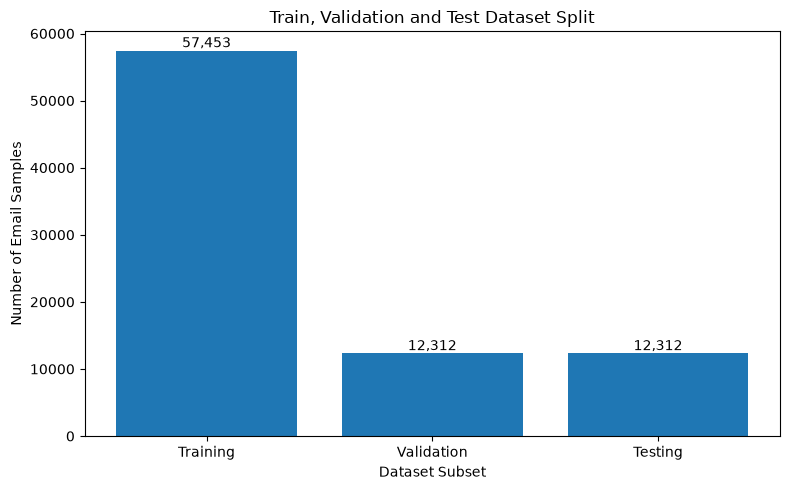

In [32]:
import matplotlib.pyplot as plt

split_names = ["Training", "Validation", "Testing"]
split_sizes = [
    len(X_train),
    len(X_val),
    len(X_test)
]

plt.figure(figsize=(8, 5))
plt.bar(split_names, split_sizes)
plt.title("Train, Validation and Test Dataset Split")
plt.xlabel("Dataset Subset")
plt.ylabel("Number of Email Samples")

for i, value in enumerate(split_sizes):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [33]:
train_indices = set(X_train.index)
val_indices = set(X_val.index)
test_indices = set(X_test.index)

train_val_overlap = train_indices.intersection(val_indices)
train_test_overlap = train_indices.intersection(test_indices)
val_test_overlap = val_indices.intersection(test_indices)

print("=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)
print(f"Train ↔ Validation overlap: {len(train_val_overlap)}")
print(f"Train ↔ Test overlap:       {len(train_test_overlap)}")
print(f"Validation ↔ Test overlap:  {len(val_test_overlap)}")


DATA LEAKAGE CHECK
Train ↔ Validation overlap: 0
Train ↔ Test overlap:       0
Validation ↔ Test overlap:  0


In [34]:
assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\nData leakage check passed.")



Data leakage check passed.


In [35]:
train_texts = set(X_train)
val_texts = set(X_val)
test_texts = set(X_test)

print("=" * 60)
print("TEXT OVERLAP CHECK")
print("=" * 60)
print(
    "Train ↔ Validation duplicate texts:",
    len(train_texts.intersection(val_texts))
)
print(
    "Train ↔ Test duplicate texts:",
    len(train_texts.intersection(test_texts))
)
print(
    "Validation ↔ Test duplicate texts:",
    len(val_texts.intersection(test_texts))
)


TEXT OVERLAP CHECK
Train ↔ Validation duplicate texts: 0
Train ↔ Test duplicate texts: 0
Validation ↔ Test duplicate texts: 0


In [36]:
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

val_df = pd.DataFrame({
    "text": X_val,
    "label": y_val
})

test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "validation.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)

print("Processed dataset splits saved successfully.")


Processed dataset splits saved successfully.


In [37]:
print("=" * 70)
print("DATA PREPARATION SUMMARY")
print("=" * 70)
print(f"Original rows:          {rows_before:,}")
print(f"Duplicates removed:     {duplicates_removed:,}")
print(f"Clean rows:             {len(df_clean):,}")
print()
print(f"Training samples:       {len(X_train):,} ({train_pct:.2f}%)")
print(f"Validation samples:     {len(X_val):,} ({val_pct:.2f}%)")
print(f"Testing samples:        {len(X_test):,} ({test_pct:.2f}%)")
print()
print("Stratified split:       YES")
print("Random seed:            42")
print("Training/test overlap:  NONE")
print()
print("IMPORTANT:")
print("No vectorizer or learned preprocessing has been fitted yet.")
print("The TF-IDF vectorizer will be fitted ONLY on the training set.")


DATA PREPARATION SUMMARY
Original rows:          82,486
Duplicates removed:     408
Clean rows:             82,077

Training samples:       57,453 (70.00%)
Validation samples:     12,312 (15.00%)
Testing samples:        12,312 (15.00%)

Stratified split:       YES
Random seed:            42
Training/test overlap:  NONE

IMPORTANT:
No vectorizer or learned preprocessing has been fitted yet.
The TF-IDF vectorizer will be fitted ONLY on the training set.


### Dataset Preparation Interpretation

The dataset was cleaned before model development to reduce the risk of
artificially inflated performance. Exact duplicate records were removed
before dataset splitting so that identical email records could not occur
across training and evaluation subsets.

A stratified 70/15/15 split was then applied. Stratification preserves the
relative proportions of legitimate and phishing emails in the training,
validation and testing sets.

The testing subset will not be used during model selection, preprocessing
fitting, hyperparameter tuning or early stopping. It will only be used for
final model evaluation.

To prevent data leakage, the text vectorisation model will be fitted using
the training set only. The fitted vectoriser will subsequently transform
the validation and testing sets.


## 4. TF-IDF Feature Engineering and Baseline Model

Before developing the deep learning model, a Logistic Regression classifier
is trained as a baseline.

The raw email messages cannot be passed directly to a traditional machine
learning classifier. Therefore, TF-IDF (Term Frequency-Inverse Document
Frequency) is used to convert the email text into numerical feature vectors.

To prevent data leakage, the TF-IDF vectorizer is fitted exclusively on the
training set. The fitted vectorizer is then used to transform the validation
and test sets without learning any information from them.

The baseline model will be evaluated using the validation set. The test set
will remain untouched until final model evaluation.


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import joblib
import time


In [39]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    dtype=np.float32
)

print(tfidf_vectorizer)


TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.98, max_features=50000,
                min_df=2, ngram_range=(1, 2), strip_accents='unicode',
                sublinear_tf=True)


In [40]:
print("=" * 70)
print("TF-IDF TRAINING")
print("=" * 70)

tfidf_start = time.time()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

tfidf_time = time.time() - tfidf_start

print(f"Training documents: {X_train_tfidf.shape[0]:,}")
print(f"TF-IDF features:     {X_train_tfidf.shape[1]:,}")
print(f"Fit time:            {tfidf_time:.2f} seconds")
print()
print("IMPORTANT:")
print("TF-IDF was fitted ONLY on the training set.")


TF-IDF TRAINING


Training documents: 57,453
TF-IDF features:     50,000
Fit time:            37.29 seconds

IMPORTANT:
TF-IDF was fitted ONLY on the training set.


In [41]:
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("=" * 70)
print("TF-IDF TRANSFORMED DATASETS")
print("=" * 70)
print(f"Training shape:   {X_train_tfidf.shape}")
print(f"Validation shape: {X_val_tfidf.shape}")
print(f"Testing shape:    {X_test_tfidf.shape}")


TF-IDF TRANSFORMED DATASETS
Training shape:   (57453, 50000)
Validation shape: (12312, 50000)
Testing shape:    (12312, 50000)


In [42]:
assert X_train_tfidf.shape[1] == X_val_tfidf.shape[1]
assert X_train_tfidf.shape[1] == X_test_tfidf.shape[1]

print("Feature-dimension validation passed.")


Feature-dimension validation passed.


In [43]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("=" * 70)
print("TF-IDF VOCABULARY")
print("=" * 70)
print(f"Vocabulary size: {len(feature_names):,}")
print()
print("First 30 features:")
print(feature_names[:30])


TF-IDF VOCABULARY
Vocabulary size: 50,000

First 30 features:
['00' '00 00' '00 000' '00 01' '00 010' '00 02' '00 10' '00 11' '00 12'
 '00 14' '00 15' '00 16' '00 17' '00 18' '00 20' '00 23' '00 25' '00 30'
 '00 31' '00 40' '00 45' '00 50' '00 60' '00 90' '00 adobe' '00 also'
 '00 cash' '00 coffee' '00 cst' '00 daren']


### 4.1 Logistic Regression Baseline

Logistic Regression is used as the baseline classifier because it performs
well on high-dimensional sparse text representations such as TF-IDF.

The baseline establishes a reference level of performance that can later be
compared with the deep learning model.


In [44]:
baseline_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="liblinear",
    random_state=SEED
)

print(baseline_model)


LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')


In [45]:
print("=" * 70)
print("TRAINING LOGISTIC REGRESSION BASELINE")
print("=" * 70)

baseline_start = time.time()

baseline_model.fit(X_train_tfidf, y_train)

baseline_training_time = time.time() - baseline_start

print("Baseline training completed.")
print(f"Training time: {baseline_training_time:.2f} seconds")


TRAINING LOGISTIC REGRESSION BASELINE


Baseline training completed.
Training time: 1.99 seconds


In [46]:
baseline_val_pred = baseline_model.predict(X_val_tfidf)
baseline_val_prob = baseline_model.predict_proba(
    X_val_tfidf
)[:, 1]

print("Validation predictions generated.")


Validation predictions generated.


In [47]:
baseline_accuracy = accuracy_score(
    y_val,
    baseline_val_pred
)

baseline_precision = precision_score(
    y_val,
    baseline_val_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_val,
    baseline_val_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_val,
    baseline_val_pred,
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_val,
    baseline_val_prob
)

baseline_loss = log_loss(
    y_val,
    baseline_val_prob
)

baseline_pr_auc = average_precision_score(
    y_val,
    baseline_val_prob
)


In [48]:
print("=" * 70)
print("BASELINE VALIDATION RESULTS")
print("=" * 70)
print(f"Accuracy:     {baseline_accuracy:.4f}")
print(f"Precision:    {baseline_precision:.4f}")
print(f"Recall:       {baseline_recall:.4f}")
print(f"F1-score:     {baseline_f1:.4f}")
print(f"ROC-AUC:      {baseline_roc_auc:.4f}")
print(f"PR-AUC:       {baseline_pr_auc:.4f}")
print(f"Log Loss:     {baseline_loss:.4f}")


BASELINE VALIDATION RESULTS
Accuracy:     0.9895
Precision:    0.9864
Recall:       0.9936
F1-score:     0.9900
ROC-AUC:      0.9991
PR-AUC:       0.9991
Log Loss:     0.0733


In [49]:
baseline_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss"
    ],
    "Validation Score": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc,
        baseline_pr_auc,
        baseline_loss
    ]
})

display(
    baseline_metrics.style.format({
        "Validation Score": "{:.4f}"
    })
)


,Metric,Validation Score
0,Accuracy,0.9895
1,Precision,0.9864
2,Recall,0.9936
3,F1-score,0.9900
4,ROC-AUC,0.9991
5,PR-AUC,0.9991
6,Log Loss,0.0733


In [50]:
print("=" * 70)
print("CLASSIFICATION REPORT — BASELINE VALIDATION SET")
print("=" * 70)

print(
    classification_report(
        y_val,
        baseline_val_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)


CLASSIFICATION REPORT — BASELINE VALIDATION SET
              precision    recall  f1-score   support

  Legitimate     0.9930    0.9850    0.9890      5885
    Phishing     0.9864    0.9936    0.9900      6427

    accuracy                         0.9895     12312
   macro avg     0.9897    0.9893    0.9895     12312
weighted avg     0.9895    0.9895    0.9895     12312



In [51]:
baseline_cm = confusion_matrix(
    y_val,
    baseline_val_pred
)

print("Confusion Matrix:")
print(baseline_cm)


Confusion Matrix:
[[5797   88]
 [  41 6386]]


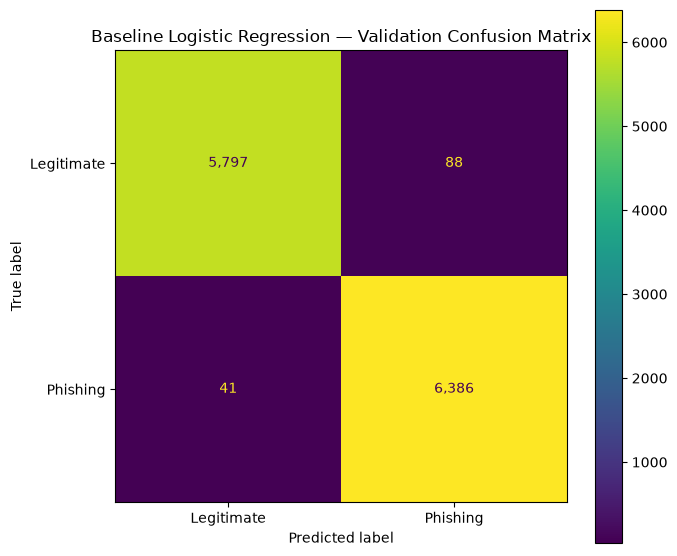

In [52]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=[
        "Legitimate",
        "Phishing"
    ]
).plot(
    ax=ax,
    values_format=",d"
)

plt.title(
    "Baseline Logistic Regression — Validation Confusion Matrix"
)
plt.tight_layout()
plt.show()


In [53]:
tn, fp, fn, tp = baseline_cm.ravel()

print("=" * 70)
print("CONFUSION MATRIX INTERPRETATION")
print("=" * 70)
print(f"True Negatives  (Legitimate correctly identified): {tn:,}")
print(f"False Positives (Legitimate flagged as phishing):  {fp:,}")
print(f"False Negatives (Phishing missed):                  {fn:,}")
print(f"True Positives  (Phishing correctly detected):      {tp:,}")


CONFUSION MATRIX INTERPRETATION
True Negatives  (Legitimate correctly identified): 5,797
False Positives (Legitimate flagged as phishing):  88
False Negatives (Phishing missed):                  41
True Positives  (Phishing correctly detected):      6,386


In [54]:
baseline_fpr = fp / (fp + tn)
baseline_fnr = fn / (fn + tp)

print("=" * 70)
print("CYBERSECURITY ERROR RATES")
print("=" * 70)
print(f"False Positive Rate (FPR): {baseline_fpr:.4f}")
print(f"False Negative Rate (FNR): {baseline_fnr:.4f}")


CYBERSECURITY ERROR RATES
False Positive Rate (FPR): 0.0150
False Negative Rate (FNR): 0.0064


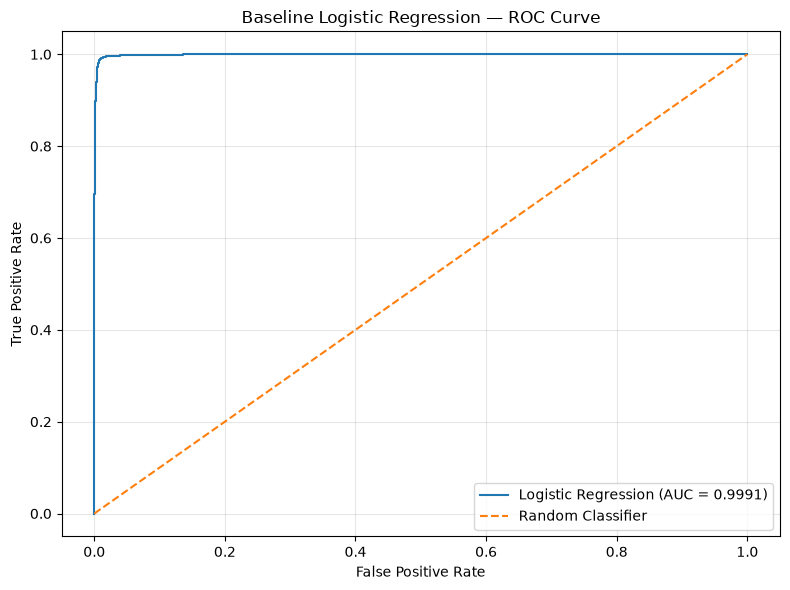

In [55]:
fpr, tpr, roc_thresholds = roc_curve(
    y_val,
    baseline_val_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {baseline_roc_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Baseline Logistic Regression — ROC Curve"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


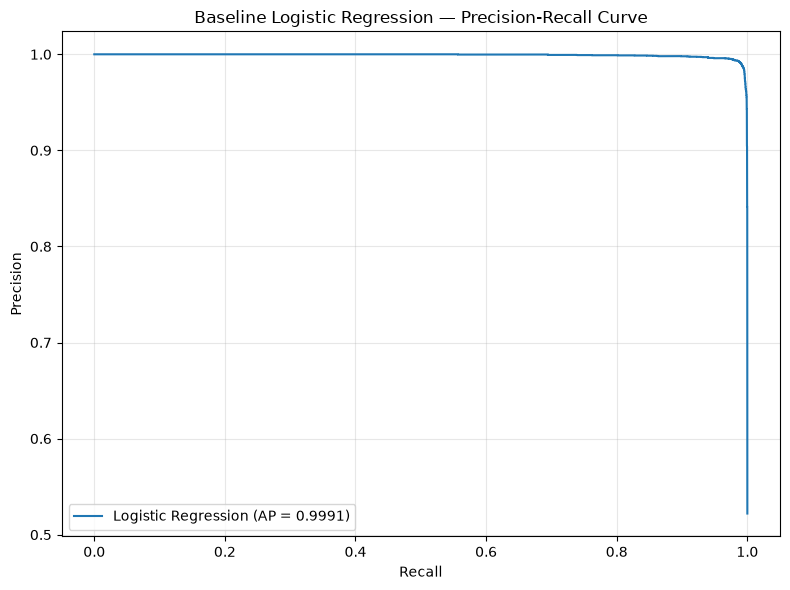

In [56]:
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    y_val,
    baseline_val_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    pr_recall,
    pr_precision,
    label=f"Logistic Regression (AP = {baseline_pr_auc:.4f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Baseline Logistic Regression — Precision-Recall Curve"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [57]:
coefficients = baseline_model.coef_[0]

top_phishing_indices = np.argsort(coefficients)[-20:][::-1]
top_legitimate_indices = np.argsort(coefficients)[:20]

top_phishing_features = pd.DataFrame({
    "Feature": feature_names[top_phishing_indices],
    "Coefficient": coefficients[top_phishing_indices]
})

top_legitimate_features = pd.DataFrame({
    "Feature": feature_names[top_legitimate_indices],
    "Coefficient": coefficients[top_legitimate_indices]
})

print("Features most associated with PHISHING:")
display(top_phishing_features)

print("\nFeatures most associated with LEGITIMATE email:")
display(top_legitimate_features)


Features most associated with PHISHING:


,Feature,Coefficient
0,love,5.096695
1,0300,5.070804
2,life,5.011410
3,account,4.890684
4,click,4.801722
5,http,4.768083
6,josemonkeyorg,4.707266
7,money,4.636498
8,com,4.337226
9,2004,4.334413



Features most associated with LEGITIMATE email:


,Feature,Coefficient
0,wrote,-10.342199
1,enron,-9.888571
2,thanks,-7.535528
3,university,-5.441834
4,opensuse,-5.411622
5,vince,-5.254142
6,louise,-4.498318
7,im,-4.469952
8,would,-4.312195
9,list,-4.193453


In [58]:
BASELINE_MODEL_DIR = Path(
    "../models/baseline"
)
BASELINE_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    tfidf_vectorizer,
    BASELINE_MODEL_DIR / "tfidf_vectorizer.joblib"
)

joblib.dump(
    baseline_model,
    BASELINE_MODEL_DIR / "logistic_regression.joblib"
)

print("Baseline model artifacts saved successfully.")


Baseline model artifacts saved successfully.


In [59]:
for artifact in BASELINE_MODEL_DIR.iterdir():
    size_mb = artifact.stat().st_size / (1024 ** 2)
    print(
        f"{artifact.name}: {size_mb:.2f} MB"
    )


logistic_regression.joblib: 0.38 MB
tfidf_vectorizer.joblib: 1.75 MB


In [60]:
BASELINE_METRICS_PATH = Path(
    "../outputs/metrics/baseline_validation_metrics.csv"
)

baseline_metrics.to_csv(
    BASELINE_METRICS_PATH,
    index=False
)

print(
    f"Baseline metrics saved to: {BASELINE_METRICS_PATH}"
)


Baseline metrics saved to: ..\outputs\metrics\baseline_validation_metrics.csv


In [61]:
print("=" * 70)
print("BASELINE MODEL SUMMARY")
print("=" * 70)
print("Model:                  Logistic Regression")
print("Feature representation: TF-IDF")
print(f"Vocabulary size:        {len(feature_names):,}")
print()
print(f"Training samples:       {len(X_train):,}")
print(f"Validation samples:     {len(X_val):,}")
print()
print(f"Accuracy:               {baseline_accuracy:.4f}")
print(f"Precision:              {baseline_precision:.4f}")
print(f"Recall:                 {baseline_recall:.4f}")
print(f"F1-score:               {baseline_f1:.4f}")
print(f"ROC-AUC:                {baseline_roc_auc:.4f}")
print(f"PR-AUC:                 {baseline_pr_auc:.4f}")
print(f"Log Loss:               {baseline_loss:.4f}")
print()
print(f"False Positive Rate:    {baseline_fpr:.4f}")
print(f"False Negative Rate:    {baseline_fnr:.4f}")
print()
print("Test set evaluated:     NO")


BASELINE MODEL SUMMARY
Model:                  Logistic Regression
Feature representation: TF-IDF
Vocabulary size:        50,000

Training samples:       57,453
Validation samples:     12,312

Accuracy:               0.9895
Precision:              0.9864
Recall:                 0.9936
F1-score:               0.9900
ROC-AUC:                0.9991
PR-AUC:                 0.9991
Log Loss:               0.0733

False Positive Rate:    0.0150
False Negative Rate:    0.0064

Test set evaluated:     NO


### Baseline Interpretation

The Logistic Regression model establishes a traditional machine learning
baseline for phishing email classification.

The validation results provide a reference against which the subsequent
deep learning model can be compared.

Particular attention is given to recall, F1-score, ROC-AUC and the false
negative rate because incorrectly classifying a phishing message as
legitimate may expose a user to malicious content.

The independent test set has not been evaluated at this stage. It remains
reserved for final evaluation after model selection has been completed.


## 5. Deep Learning Model

A one-dimensional Convolutional Neural Network (1D CNN) is developed as the
main deep learning model for phishing email classification.

Unlike the TF-IDF Logistic Regression baseline, the deep learning model
learns distributed word representations through an embedding layer and
detects local textual patterns using convolutional filters.

The model architecture consists of:

1. Text vectorisation
2. Word embedding
3. Spatial dropout
4. One-dimensional convolution
5. Global max pooling
6. Fully connected hidden layers
7. Batch normalisation
8. Dropout regularisation
9. Sigmoid binary classification output

The text vectorisation layer is adapted exclusively on the training set to
prevent information leakage from the validation and testing datasets.

The independent test set remains unused during model development.


In [62]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.21.0
Keras version: 3.15.1


In [63]:
print("=" * 70)
print("DATASET STATUS BEFORE DEEP LEARNING")
print("=" * 70)
print(f"Training samples:   {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Testing samples:    {len(X_test):,}")
print()
print("Test labels used for model selection: NO")
print("Test set evaluation performed:       NO")


DATASET STATUS BEFORE DEEP LEARNING
Training samples:   57,453
Validation samples: 12,312
Testing samples:    12,312

Test labels used for model selection: NO
Test set evaluation performed:       NO


### 5.1 Model Configuration

The network uses a controlled vocabulary and fixed sequence length to provide
consistent input dimensions.

The selected configuration balances modelling capacity and computational
efficiency so that the model can identify phishing-related phrases and local
textual patterns without creating an unnecessarily large architecture.


In [64]:
MAX_TOKENS = 30000
SEQUENCE_LENGTH = 300
EMBEDDING_DIM = 64
CONV_FILTERS = 128
KERNEL_SIZE = 5
BATCH_SIZE = 256
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3

print("=" * 70)
print("DEEP LEARNING CONFIGURATION")
print("=" * 70)
print(f"Maximum vocabulary size: {MAX_TOKENS:,}")
print(f"Sequence length:          {SEQUENCE_LENGTH}")
print(f"Embedding dimensions:     {EMBEDDING_DIM}")
print(f"Convolution filters:      {CONV_FILTERS}")
print(f"Convolution kernel size:  {KERNEL_SIZE}")
print(f"Batch size:               {BATCH_SIZE}")
print(f"Maximum epochs:           {MAX_EPOCHS}")
print(f"Early stopping patience:  {EARLY_STOPPING_PATIENCE}")


DEEP LEARNING CONFIGURATION
Maximum vocabulary size: 30,000
Sequence length:          300
Embedding dimensions:     64
Convolution filters:      128
Convolution kernel size:  5
Batch size:               256
Maximum epochs:           20
Early stopping patience:  3


In [65]:
text_vectorizer_dl = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize=None,
    name="text_vectorization"
)

print(text_vectorizer_dl)


<TextVectorization name=text_vectorization, built=False>


In [66]:
print("=" * 70)
print("ADAPTING DEEP LEARNING TEXT VECTORIZER")
print("=" * 70)

vectorizer_start = time.time()

text_vectorizer_dl.adapt(
    X_train.astype(str).to_numpy()
)

vectorizer_time = time.time() - vectorizer_start

print("Text vectorizer adaptation completed.")
print(f"Adaptation time: {vectorizer_time:.2f} seconds")
print()
print("IMPORTANT:")
print("The vectorizer was adapted ONLY using training emails.")


ADAPTING DEEP LEARNING TEXT VECTORIZER


Text vectorizer adaptation completed.
Adaptation time: 3.28 seconds

IMPORTANT:
The vectorizer was adapted ONLY using training emails.


In [67]:
dl_vocabulary = text_vectorizer_dl.get_vocabulary()

print("=" * 70)
print("DEEP LEARNING VOCABULARY")
print("=" * 70)
print(f"Vocabulary size: {len(dl_vocabulary):,}")
print("\nFirst 30 vocabulary entries:")
print(dl_vocabulary[:30])


DEEP LEARNING VOCABULARY
Vocabulary size: 30,000

First 30 vocabulary entries:
['', '[UNK]', np.str_('_'), np.str_('2008'), np.str_('1'), np.str_('enron'), np.str_('aug'), np.str_('10'), np.str_('email'), np.str_('submissionid'), np.str_('please'), np.str_('2'), np.str_('one'), np.str_('new'), np.str_('ect'), np.str_('3'), np.str_('would'), np.str_('0'), np.str_('time'), np.str_('company'), np.str_('information'), np.str_('get'), np.str_('5'), np.str_('top'), np.str_('us'), np.str_('added'), np.str_('submission'), np.str_('may'), np.str_('sender'), np.str_('notes')]


In [68]:
sample_email = X_train.iloc[0]
sample_vector = text_vectorizer_dl(
    tf.constant([sample_email])
)

print("Original email excerpt:")
print(sample_email[:500])

print("\nVectorized representation:")
print(sample_vector.numpy()[0][:50])

print("\nVector shape:")
print(sample_vector.shape)


Original email excerpt:
daily top 10 tnacav1_1986phbscom daily top 10 cnncom top videos stories aug 1 2008 358 pm edt top 10 videos 1 paris hilton takes mccain httpwwwcnncomvideopartnersemailindexhtmlurlvideopolitics20080806wynterparishiltonadcnn paris hilton swings back republican presidential candidate john mccain kareen wynter reports 2 bikini barista stand closed httpwwwcnncomvideopartnersemailindexhtmlurlvideoliving20080806pkgbikinibaristasbarredkiro 3 tot grandma reacts charges httpwwwcnncomvideopartnersemailinde

Vectorized representation:
[  70   23    7    1   70   23    7   71   23  268  259    6    4    3
  697   59  595   23    7  268    4  808  994  755  694 2253  808  994
 2025  125 1872 1817 1217  149  694 2232 2235  379   11 2170 2249  780
  743 2257   15 2075 2122 2185 1089 2260]

Vector shape:
(1, 300)


In [69]:
X_train_array = X_train.astype(str).to_numpy()
X_val_array = X_val.astype(str).to_numpy()

y_train_array = (
    y_train
    .astype("float32")
    .to_numpy()
    .reshape(-1, 1)
)

y_val_array = (
    y_val
    .astype("float32")
    .to_numpy()
    .reshape(-1, 1)
)


In [70]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_train_array,
        y_train_array
    )
)

train_ds = (
    train_ds
    .shuffle(
        buffer_size=10000,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [71]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_val_array,
        y_val_array
    )
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("TensorFlow datasets created.")


TensorFlow datasets created.


In [72]:
for batch_text, batch_labels in train_ds.take(1):
    print("Text batch shape:", batch_text.shape)
    print("Label batch shape:", batch_labels.shape)
    print()
    print("First label:", batch_labels[0].numpy())
    print()
    print("First email excerpt:")
    print(batch_text[0].numpy().decode("utf-8")[:500])


Text batch shape: (256,)
Label batch shape: (256, 1)

First label: [0.]

First email excerpt:
global risk management friday may 5 2000 rick buy jeff skillling signed memo designating john lavorato western hemishere john sherriff eastern hemisphere responsible parties signing daily positiion report please obtain greg whalley approval dpr prior date going forward please coordinate preferred method designating approval assume use e mail time executive reports viewer changed accomodate change also assume working solution unless otherwise informed john sherriff john lavorato memo exactly sent


In [73]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

email_input = keras.Input(
    shape=(),
    dtype=tf.string,
    name="email_text"
)

x = text_vectorizer_dl(email_input)

x = layers.Embedding(
    input_dim=len(dl_vocabulary),
    output_dim=EMBEDDING_DIM,
    name="embedding"
)(x)

x = layers.SpatialDropout1D(
    0.20,
    name="spatial_dropout"
)(x)

x = layers.Conv1D(
    filters=CONV_FILTERS,
    kernel_size=KERNEL_SIZE,
    activation="relu",
    name="conv1d"
)(x)

x = layers.GlobalMaxPooling1D(
    name="global_max_pooling"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    name="dense_128"
)(x)

x = layers.BatchNormalization(
    name="batch_normalization"
)(x)

x = layers.Dropout(
    0.30,
    name="dropout_1"
)(x)

x = layers.Dense(
    64,
    activation="relu",
    name="dense_64"
)(x)

x = layers.Dropout(
    0.30,
    name="dropout_2"
)(x)

phishing_probability = layers.Dense(
    1,
    activation="sigmoid",
    name="phishing_probability"
)(x)

dnn_model = keras.Model(
    inputs=email_input,
    outputs=phishing_probability,
    name="phishing_email_cnn"
)


In [74]:
dnn_model.summary()


Model: "phishing_email_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ email_text (InputLayer)         │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 300, 64)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 300, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 296, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling              │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ phishing_probability (Dense)    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,986,433 (7.58 MB)

 Trainable params: 1,986,177 (7.58 MB)

 Non-trainable params: 256 (1.00 KB)

In [75]:
dnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        keras.metrics.Precision(
            name="precision"
        ),
        keras.metrics.Recall(
            name="recall"
        ),
        keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),
        keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),
        keras.metrics.F1Score(
            name="f1_score",
            average="micro",
            threshold=0.5
        )
    ]
)


In [76]:
DEEP_MODEL_DIR = Path(
    "../models/deep_learning"
)
DEEP_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DEEP_METRICS_DIR = Path(
    "../outputs/metrics"
)
DEEP_METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DEEP_FIGURES_DIR = Path(
    "../outputs/figures"
)
DEEP_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    DEEP_MODEL_DIR /
    "best_phishing_cnn.keras"
)

TRAINING_LOG_PATH = (
    DEEP_METRICS_DIR /
    "deep_learning_training_log.csv"
)


In [77]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=0.001,
    mode="min",
    restore_best_weights=True,
    verbose=1
)


In [78]:
model_checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)


In [79]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


In [80]:
csv_logger = CSVLogger(
    TRAINING_LOG_PATH,
    append=False
)


In [81]:
callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr,
    csv_logger
]

print("Callbacks configured:")
print("- EarlyStopping")
print("- ModelCheckpoint")
print("- ReduceLROnPlateau")
print("- CSVLogger")


Callbacks configured:
- EarlyStopping
- ModelCheckpoint
- ReduceLROnPlateau
- CSVLogger


In [82]:
print("=" * 70)
print("TRAINING PHISHING EMAIL CNN")
print("=" * 70)

training_start = time.time()

history = dnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

deep_training_time = (
    time.time() - training_start
)

print()
print("=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)
print(
    f"Total training time: "
    f"{deep_training_time:.2f} seconds"
)


TRAINING PHISHING EMAIL CNN
Epoch 1/20


C:\Users\LwaziJunior\OneDrive - CTU Training Solutions (PTY) Ltd\Documents\ITRI 625 Machine Learning Project\ITRI625-Phishing-Email-Detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/225 ━━━━━━━━━━━━━━━━━━━━ 9:19 2s/step - accuracy: 0.5117 - f1_score: 0.6377 - loss: 0.7193 - pr_auc: 0.5440 - precision: 0.5366 - recall: 0.7857 - roc_auc: 0.4878

  2/225 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.5508 - f1_score: 0.6695 - loss: 0.7023 - pr_auc: 0.5671 - precision: 0.5628 - recall: 0.8262 - roc_auc: 0.5225

  3/225 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.5651 - f1_score: 0.6751 - loss: 0.6889 - pr_auc: 0.6060 - precision: 0.5698 - recall: 0.8282 - roc_auc: 0.5580

...


Epoch 6: val_loss did not improve from 0.03094


225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - accuracy: 0.9991 - f1_score: 0.9992 - loss: 0.0028 - pr_auc: 1.0000 - precision: 0.9992 - recall: 0.9992 - roc_auc: 1.0000 - val_accuracy: 0.9920 - val_f1_score: 0.9924 - val_loss: 0.0369 - val_pr_auc: 0.9955 - val_precision: 0.9893 - val_recall: 0.9955 - val_roc_auc: 0.9972 - learning_rate: 5.0000e-04


Epoch 6: early stopping


Restoring model weights from the end of the best epoch: 3.



TRAINING COMPLETED
Total training time: 126.08 seconds


In [83]:
history_df = pd.DataFrame(
    history.history
)

history_df.insert(
    0,
    "epoch",
    range(1, len(history_df) + 1)
)

display(history_df)


,epoch,accuracy,f1_score,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_f1_score,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
0,1,0.943711,0.946471,0.130353,0.990225,0.939690,0.953351,0.989708,0.982212,0.982727,0.166712,0.999387,0.996481,0.969348,0.999326,0.0010
1,2,0.996206,0.996366,0.012978,0.999602,0.996299,0.996432,0.999665,0.980101,0.980628,0.055697,0.999378,0.996945,0.964836,0.999245,0.0010
2,3,0.998346,0.998416,0.005242,0.999865,0.998499,0.998333,0.999897,0.992040,0.992388,0.030935,0.997368,0.990848,0.993932,0.998203,0.0010
3,4,0.998834,0.998883,0.003761,0.999805,0.998800,0.998966,0.999867,0.991066,0.991479,0.039384,0.996117,0.987197,0.995799,0.997474,0.0010
4,5,0.998642,0.998699,0.004018,0.999940,0.998733,0.998666,0.999941,0.990091,0.990498,0.039141,0.996794,0.991580,0.989420,0.997450,0.0010
5,6,0.999130,0.999166,0.002753,0.999963,0.999166,0.999166,0.999978,0.992040,0.992400,0.036862,0.995522,0.989330,0.995488,0.997167,0.0005


In [84]:
epochs_completed = len(
    history.history["loss"]
)

best_epoch = (
    np.argmin(
        history.history["val_loss"]
    ) + 1
)

print("=" * 70)
print("EARLY STOPPING SUMMARY")
print("=" * 70)
print(f"Maximum epochs allowed: {MAX_EPOCHS}")
print(f"Epochs completed:       {epochs_completed}")
print(f"Best epoch:             {best_epoch}")
print(
    f"Early stopping patience: "
    f"{EARLY_STOPPING_PATIENCE}"
)


EARLY STOPPING SUMMARY
Maximum epochs allowed: 20
Epochs completed:       6
Best epoch:             3
Early stopping patience: 3


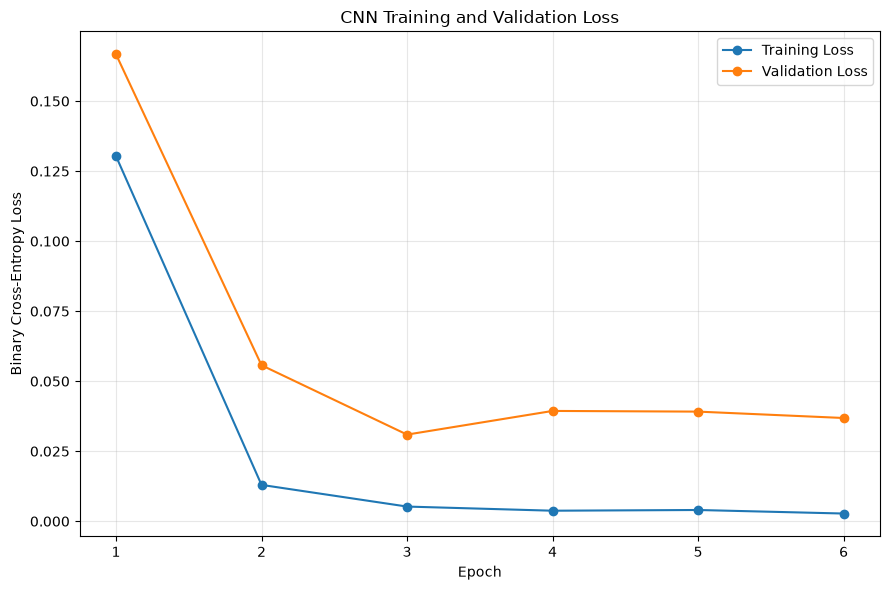

In [85]:
plt.figure(figsize=(9, 6))
plt.plot(
    history_df["epoch"],
    history_df["loss"],
    marker="o",
    label="Training Loss"
)
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title(
    "CNN Training and Validation Loss"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    DEEP_FIGURES_DIR /
    "cnn_training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


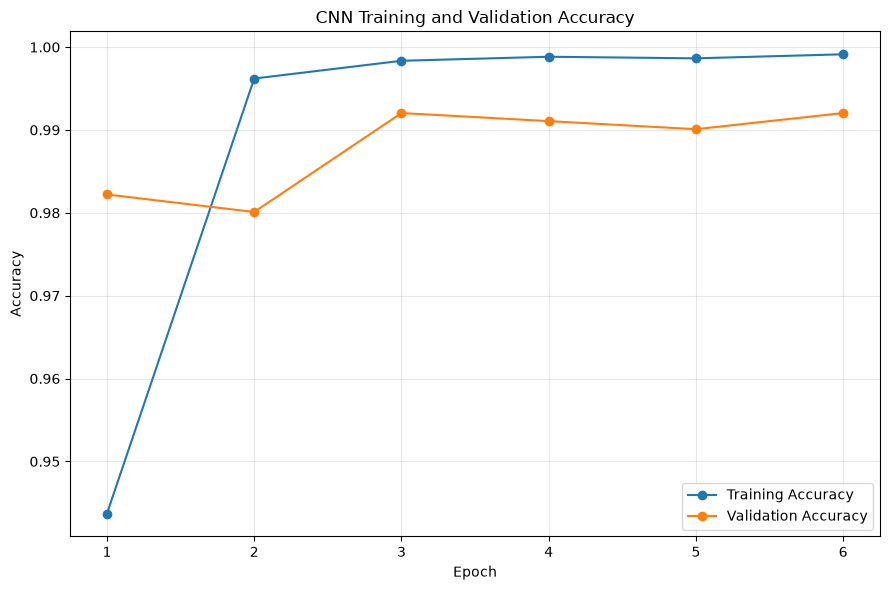

In [86]:
plt.figure(figsize=(9, 6))
plt.plot(
    history_df["epoch"],
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "CNN Training and Validation Accuracy"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    DEEP_FIGURES_DIR /
    "cnn_training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


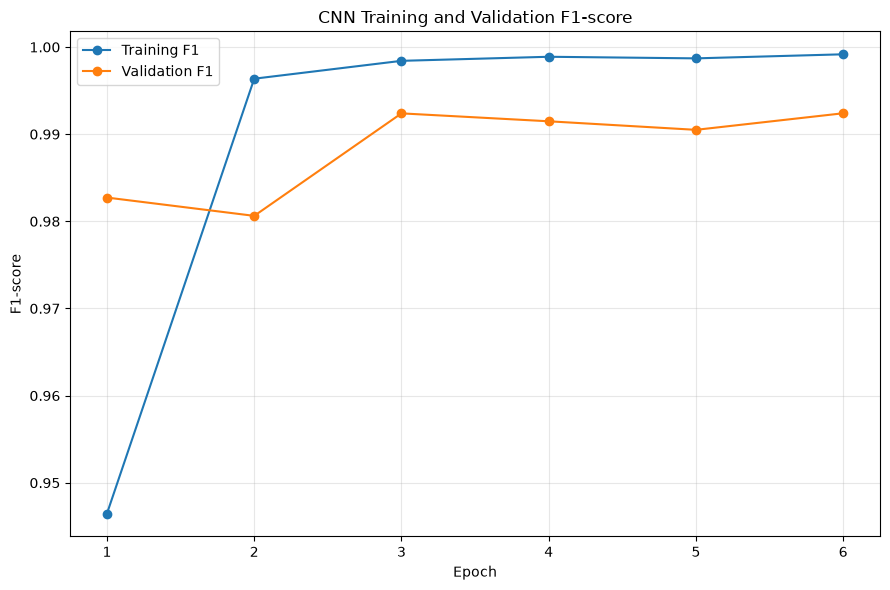

In [87]:
plt.figure(figsize=(9, 6))
plt.plot(
    history_df["epoch"],
    history_df["f1_score"],
    marker="o",
    label="Training F1"
)
plt.plot(
    history_df["epoch"],
    history_df["val_f1_score"],
    marker="o",
    label="Validation F1"
)
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title(
    "CNN Training and Validation F1-score"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    DEEP_FIGURES_DIR /
    "cnn_training_validation_f1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


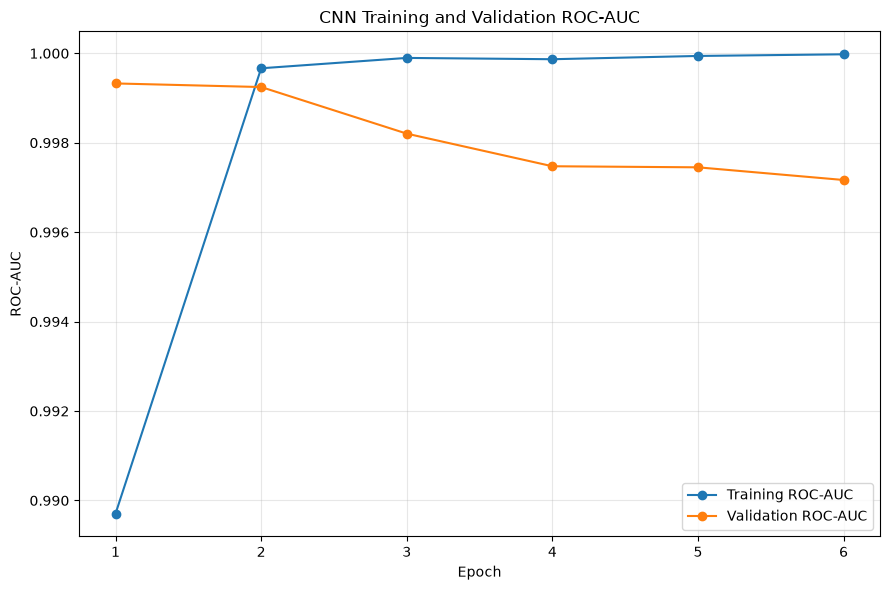

In [88]:
plt.figure(figsize=(9, 6))
plt.plot(
    history_df["epoch"],
    history_df["roc_auc"],
    marker="o",
    label="Training ROC-AUC"
)
plt.plot(
    history_df["epoch"],
    history_df["val_roc_auc"],
    marker="o",
    label="Validation ROC-AUC"
)
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title(
    "CNN Training and Validation ROC-AUC"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    DEEP_FIGURES_DIR /
    "cnn_training_validation_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [89]:
validation_results = dnn_model.evaluate(
    val_ds,
    verbose=1,
    return_dict=True
)

print("=" * 70)
print("BEST CNN — VALIDATION RESULTS")
print("=" * 70)

for metric_name, metric_value in validation_results.items():
    print(
        f"{metric_name:15s}: "
        f"{metric_value:.4f}"
    )


 1/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9883 - f1_score: 0.9892 - loss: 0.0570 - pr_auc: 0.9853 - precision: 0.9787 - recall: 1.0000 - roc_auc: 0.9913

 4/49 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9912 - f1_score: 0.9915 - loss: 0.0310 - pr_auc: 0.9960 - precision: 0.9868 - recall: 0.9962 - roc_auc: 0.9978

 7/49 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9933 - f1_score: 0.9935 - loss: 0.0245 - pr_auc: 0.9974 - precision: 0.9913 - recall: 0.9957 - roc_auc: 0.9982

10/49 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9934 - f1_score: 0.9937 - loss: 0.0311 - pr_auc: 0.9972 - precision: 0.9925 - recall: 0.9948 - roc_auc: 0.9979

13/49 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9928 - f1_score: 0.9931 - loss: 0.0306 - pr_auc: 0.9970 - precision: 0.9925 - recall: 0.9936 - roc_auc: 0.9977

...

43/49 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9925 - f1_score: 0.9928 - loss: 0.0292 - pr_auc: 0.9974 - precision: 0.9911 - recall: 0.9944 - roc_auc: 0.9982

46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9924 - f1_score: 0.9928 - loss: 0.0290 - pr_auc: 0.9976 - precision: 0.9909 - recall: 0.9946 - roc_auc: 0.9983

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9920 - f1_score: 0.9924 - loss: 0.0309 - pr_auc: 0.9974 - precision: 0.9908 - recall: 0.9939 - roc_auc: 0.9982

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9920 - f1_score: 0.9924 - loss: 0.0309 - pr_auc: 0.9974 - precision: 0.9908 - recall: 0.9939 - roc_auc: 0.9982


BEST CNN — VALIDATION RESULTS
accuracy       : 0.9920
f1_score       : 0.9924
loss           : 0.0309
pr_auc         : 0.9974
precision      : 0.9908
recall         : 0.9939
roc_auc        : 0.9982


In [90]:
best_val_loss = min(
    history.history["val_loss"]
)

best_val_accuracy = max(
    history.history["val_accuracy"]
)

best_val_f1 = max(
    history.history["val_f1_score"]
)

best_val_auc = max(
    history.history["val_roc_auc"]
)

print("=" * 70)
print("DEEP LEARNING TRAINING SUMMARY")
print("=" * 70)
print(f"Architecture:          1D CNN")
print(f"Training samples:      {len(X_train):,}")
print(f"Validation samples:    {len(X_val):,}")
print()
print(f"Epochs completed:      {epochs_completed}")
print(f"Best epoch:            {best_epoch}")
print(
    f"Training time:         "
    f"{deep_training_time:.2f} sec"
)
print()
print(f"Best validation loss:     {float(best_val_loss):.4f}")
print(f"Best validation accuracy: {float(best_val_accuracy):.4f}")
print(f"Best validation F1:       {float(best_val_f1):.4f}")
print(f"Best validation ROC-AUC:  {float(best_val_auc):.4f}")
print()
print("Test set evaluated:    NO")


DEEP LEARNING TRAINING SUMMARY
Architecture:          1D CNN
Training samples:      57,453
Validation samples:    12,312

Epochs completed:      6
Best epoch:            3
Training time:         126.08 sec

Best validation loss:     0.0309
Best validation accuracy: 0.9920
Best validation F1:       0.9924
Best validation ROC-AUC:  0.9993

Test set evaluated:    NO


In [91]:
print("=" * 70)
print("MODEL CHECKPOINT")
print("=" * 70)
print(
    "Checkpoint exists:",
    BEST_MODEL_PATH.exists()
)

if BEST_MODEL_PATH.exists():
    size_mb = (
        BEST_MODEL_PATH.stat().st_size
        / (1024 ** 2)
    )
    print(
        f"Model size: {size_mb:.2f} MB"
    )
    print(
        f"Path: {BEST_MODEL_PATH}"
    )


MODEL CHECKPOINT
Checkpoint exists: True
Model size: 23.33 MB
Path: ..\models\deep_learning\best_phishing_cnn.keras


In [92]:
reloaded_cnn = keras.models.load_model(
    BEST_MODEL_PATH
)

print(
    "Best CNN model successfully "
    "reloaded from disk."
)


Best CNN model successfully reloaded from disk.


In [93]:
demo_email = X_val.iloc[0]

demo_probability = float(
    reloaded_cnn.predict(
        tf.constant([demo_email]),
        verbose=0
    )[0][0]
)

demo_prediction = (
    "Phishing"
    if demo_probability >= 0.5
    else "Legitimate"
)

print("Prediction:", demo_prediction)
print(
    f"Phishing probability: "
    f"{demo_probability:.4f}"
)
print(
    "Actual label:",
    "Phishing"
    if y_val.iloc[0] == 1
    else "Legitimate"
)


Prediction: Phishing
Phishing probability: 0.9988
Actual label: Phishing


### 5.2 Architecture Interpretation

The TextVectorization layer converts raw email text into fixed-length integer
sequences. The Embedding layer then learns dense vector representations of
the tokens during training.

A one-dimensional convolutional layer learns local textual patterns that may
be associated with phishing behaviour, including combinations of words and
short phrases. Global max pooling retains the strongest detected feature from
each convolutional filter.

The fully connected layers learn higher-level combinations of these detected
features. ReLU activation is used in the hidden layers to introduce
non-linearity, while the final sigmoid unit produces a probability between
0 and 1 for binary phishing classification.

Dropout and spatial dropout reduce overfitting by randomly disabling model
activations during training. Batch normalisation improves optimisation
stability.

Patience-based early stopping monitors validation loss and terminates
training when generalisation performance no longer improves. The best model
weights are restored and the best-performing model is preserved using a
checkpoint.
